In [22]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [23]:
#set random seed function
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
#set random seed
set_seed(42)

In [24]:
#choose cpu/gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [25]:
#load and transform data
#transform part
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3)
])
#load part
dataset = datasets.CIFAR10(
    root='./data(CIFAR10)', train=True, download=False, transform=transform
)

In [26]:
#loader data
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

In [33]:
#load U-Net
%run U-Net.ipynb
#load Compute-Loss-Mean
%run Compute-Loss-Mean-b.ipynb
%run Compute-Loss-Mean-a.ipynb

In [48]:
#plot gradient image
def plot_gradient_norm(results_dict_b, results_dict_a, use_log_scale=True):
    plt.style.use('default')
    plt.figure(figsize=(6.5, 4.5))
    #draw curves of different seeds
    for label, (bin_centers_b, mean_curve_b, stderr_curve_b) in results_dict_b.items():
        plt.plot(bin_centers_b, mean_curve_b, color='red', marker='o', linestyle='--', label=label)
        plt.fill_between(bin_centers_b, mean_curve_b - stderr_curve_b, mean_curve_b + stderr_curve_b, color='red', alpha=0.3)
    for label, (bin_centers_a, mean_curve_a, stderr_curve_a) in results_dict_a.items():
        plt.plot(bin_centers_a, mean_curve_a, color='blue', marker='o', linestyle='--', label=label)
        plt.fill_between(bin_centers_a, mean_curve_a - stderr_curve_a, mean_curve_a + stderr_curve_a, color='blue', alpha=0.3)
    plt.xlabel('Log-SNR', fontsize=13)
    plt.ylabel('Per-bin Loss Variance', fontsize=13)
    #change y scale
    if use_log_scale:
        plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(frameon=False)
    plt.title('Variance Loss VS Log-SNR (baseline & adaptive)', fontsize=14)
    ax = plt.gca()
    ax.spines['top'].set_visible('False')
    ax.spines['right'].set_visible('False')
    plt.tight_layout()
    plt.savefig('variance_comparison.pdf', dpi=600, bbox_inches='tight')
    plt.show()

In [40]:
#analyze ckpt function
def analyze_ckpt_a(ckpt_paths, loader, device):
    all_seed_bin_vars_a = []

    for ckpt_path in ckpt_paths:
        #load model
        model = UNet().to(device)
        ckpt = torch.load(ckpt_path)
        model.load_state_dict(ckpt['model'])
        model.eval()
        print(f'Checkpoint:{ckpt_path} Loaded Successfully...')

        #compute loss variance per sample
        bin_centers_a, var_loss_a, mean_loss_a, _ = compute_loss_mean_a(model, loader, device, max_batches=200)

        all_seed_bin_vars_a.append(var_loss_a)
    #compute mean & std curve
    mean_curve_a, stderr_curve_a = aggregate_across_seeds(all_seed_bin_vars_a)
    return bin_centers_a, mean_curve_a, stderr_curve_a

In [41]:
#analyze ckpt function
def analyze_ckpt_b(ckpt_paths, loader, device):
    all_seed_bin_vars_b = []

    for ckpt_path in ckpt_paths:
        #load model
        model = UNet().to(device)
        ckpt = torch.load(ckpt_path)
        model.load_state_dict(ckpt['model'])
        model.eval()
        print(f'Checkpoint:{ckpt_path} Loaded Successfully...')

        #compute loss variance per sample
        bin_centers_b, var_loss_b, mean_loss_b, _ = compute_loss_mean_b(model, loader, device, max_batches=200)

        all_seed_bin_vars_b.append(var_loss_b)
    #compute mean & std curve
    mean_curve_b, stderr_curve_b = aggregate_across_seeds(all_seed_bin_vars_b)
    return bin_centers_b, mean_curve_b, stderr_curve_b

In [42]:
#collect ckpt of different seeds
ckpt_b = ['checkpoint_b/42_step_60000_checkpoint.pth', 'checkpoint_b/142_step_60000_checkpoint.pth', 'checkpoint_b/242_step_60000_checkpoint.pth']
ckpt_a = ['checkpoint_a/42_step_60000_checkpoint.pth', 'checkpoint_a/142_step_60000_checkpoint.pth', 'checkpoint_a/242_step_60000_checkpoint.pth']

Checkpoint:checkpoint_b/42_step_60000_checkpoint.pth Loaded Successfully...
Checkpoint:checkpoint_b/142_step_60000_checkpoint.pth Loaded Successfully...
Checkpoint:checkpoint_b/242_step_60000_checkpoint.pth Loaded Successfully...
Checkpoint:checkpoint_a/42_step_60000_checkpoint.pth Loaded Successfully...
Checkpoint:checkpoint_a/142_step_60000_checkpoint.pth Loaded Successfully...
Checkpoint:checkpoint_a/242_step_60000_checkpoint.pth Loaded Successfully...


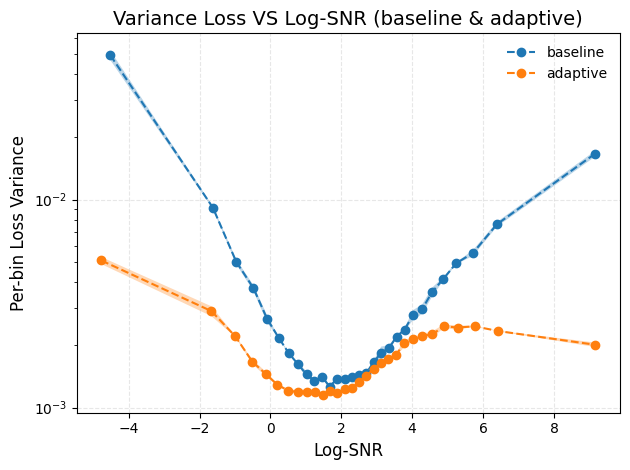

In [43]:
#compute results of different seeds
results_b = {}
results_a = {}
#ckpt - 10k
results_b['baseline'] = analyze_ckpt_b(ckpt_b, loader, device)
#ckpt - 30k
results_a['adaptive'] = analyze_ckpt_a(ckpt_a, loader, device)

plot_gradient_norm(results_b, results_a)

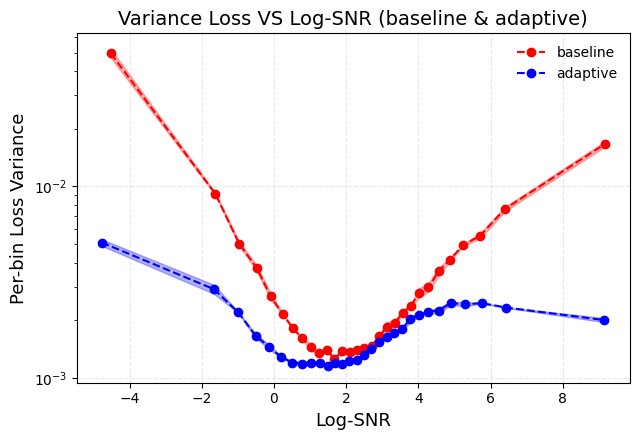

In [49]:
plot_gradient_norm(results_b, results_a)